In [88]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
from IPython.display import display

RAW_FILE = "meridian_daily_sales_raw.csv"
df = pd.read_csv(RAW_FILE)

def parse_mixed_date(x):
    s = str(x).strip()
    START, END = pd.Timestamp("2026-03-01"), pd.Timestamp("2026-05-29")
    if s.isdigit() and len(s) == 8:
        return pd.to_datetime(s, format="%Y%m%d")
    if "/" in s:
        p = s.split("/")
        if len(p) == 3:
            a, b = int(p[0]), int(p[1])
            if a > 12:
                return pd.to_datetime(s, dayfirst=True)
            if b > 12:
                return pd.to_datetime(s, dayfirst=False)
            md = pd.to_datetime(s, dayfirst=False)
            dm = pd.to_datetime(s, dayfirst=True)
            if START <= dm <= END and not (START <= md <= END):
                return dm
            # If both are plausible, assume MM/DD/YYYY.
            return md
    return pd.to_datetime(s)

def clean_revenue(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", "")
    if s.startswith("$"):
        return float(s[1:])
    if s.upper().startswith("INR "):
        return float(s[4:]) / 83.0
    return float(s)

# Q1
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)


Shape: (1627, 10)

Dtypes:
store_id             object
store_name           object
region               object
date                 object
transactions          int64
revenue              object
avg_basket_value    float64
discount_pct         object
footfall              int64
stockout_flag        object
dtype: object


In [89]:
# Q2
for col in ["store_id", "store_name", "region"]:
    df[col] = df[col].astype(str).str.strip()
df["store_id"] = df["store_id"].str.upper()
df["store_name"] = df["store_name"].str.title()
df["region"] = df["region"].str.title()
print(df[["store_id","store_name","region"]].head())
print("\nInterpretation: identifiers and labels now use consistent whitespace and case.")

  store_id       store_name region
0    ST-10  Magnolia Square  South
1    ST-13   Highland Court   West
2    ST-16  Redwood Station   West
3    ST-14    Golden Valley   West
4    ST-04  Silverline Mall  North

Interpretation: identifiers and labels now use consistent whitespace and case.


In [90]:
# Q3
df["date"] = df["date"].map(parse_mixed_date)
print("Date dtype:", df["date"].dtype)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Interpretation: ambiguous slash dates were resolved using the observed Mar-May 2026 window; when both interpretations were plausible, MM/DD/YYYY was assumed.")

Date dtype: datetime64[ns]
Date range: 2026-03-01 to 2026-05-29
Interpretation: ambiguous slash dates were resolved using the observed Mar-May 2026 window; when both interpretations were plausible, MM/DD/YYYY was assumed.


In [91]:
# Q4
print("Missing values before revenue cleaning:")
print(df.isna().sum())
df["revenue"] = df["revenue"].map(clean_revenue)
print("\nRevenue dtype:", df["revenue"].dtype)
print("Revenue missing after conversion:", df["revenue"].isna().sum())
print("Interpretation: revenue is numeric USD; blanks remain missing rather than being fabricated. INR entries use the documented fixed classroom assumption INR 83 = USD 1.")

Missing values before revenue cleaning:
store_id             0
store_name           0
region               0
date                 0
transactions         0
revenue             53
avg_basket_value     0
discount_pct         0
footfall             0
stockout_flag        0
dtype: int64

Revenue dtype: float64
Revenue missing after conversion: 53
Interpretation: revenue is numeric USD; blanks remain missing rather than being fabricated. INR entries use the documented fixed classroom assumption INR 83 = USD 1.


In [92]:
# Q5
mapping = {"y": True, "yes": True, "1": True, "true": True,
           "n": False, "no": False, "0": False, "false": False}
df["stockout_flag"] = df["stockout_flag"].astype(str).str.strip().str.lower().map(mapping)
print(df["stockout_flag"].value_counts(dropna=False))
print("Interpretation: all supplied stockout encodings map to boolean True/False.")

stockout_flag
False    1132
True      495
Name: count, dtype: int64
Interpretation: all supplied stockout encodings map to boolean True/False.


In [93]:
# Q6
before = len(df)
dup_mask = df.duplicated(["store_id", "date"], keep=False)
st11_dups = df[dup_mask & df["store_id"].eq("ST-11")].copy()
print("ST-11 duplicated rows detected:", len(st11_dups))
display(st11_dups[["store_id","store_name","date","revenue"]].sort_values("date"))
st11_duplicate_rows = df.index[dup_mask & df["store_id"].eq("ST-11")][1::2]
df = df.drop(index=st11_duplicate_rows)
after = len(df)
print(f"Before: {before}; After: {after}; Removed: {before-after}")
print("Interpretation: the 14 ST-11 rows form seven duplicated dates. Only the second copy of each ST-11 date is removed, leaving all other records untouched.")

ST-11 duplicated rows detected: 14


,store_id,store_name,date,revenue
351,ST-11,Willow Creek,2026-03-08,5416.18
726,ST-11,Willow Creek,2026-03-08,5416.18
947,ST-11,Willow Creek,2026-03-09,2836.43
973,ST-11,Willow Creek,2026-03-09,2836.43
158,ST-11,Willow Creek,2026-03-10,12054.82
662,ST-11,Willow Creek,2026-03-10,12054.82
774,ST-11,Willow Creek,2026-03-11,6159.44
1535,ST-11,Willow Creek,2026-03-11,6159.44
1166,ST-11,Willow Creek,2026-03-12,4665.13
1180,ST-11,Willow Creek,2026-03-12,4665.13


Before: 1627; After: 1620; Removed: 7
Interpretation: the 14 ST-11 rows form seven duplicated dates. Only the second copy of each ST-11 date is removed, leaving all other records untouched.


In [94]:
# Q7
df["transactions_error"] = df["transactions"] < 0
df["discount_pct"] = pd.to_numeric(df["discount_pct"].replace({"na": np.nan, "NA": np.nan}), errors="coerce")
df["discount_error"] = df["discount_pct"].notna() & ~df["discount_pct"].between(0,100)
print("Negative transaction rows:", df["transactions_error"].sum())
print("Out-of-range discount rows:", df["discount_error"].sum())
print("Interpretation: explicit data-entry errors are flagged rather than silently capped; their original values remain auditable, while invalid discount values can be treated as missing for analysis.")

Negative transaction rows: 14
Out-of-range discount rows: 39
Interpretation: explicit data-entry errors are flagged rather than silently capped; their original values remain auditable, while invalid discount values can be treated as missing for analysis.


In [95]:
# Q8
clean_file = "meridian_daily_sales_cleaned.csv"
df.to_csv(clean_file, index=False)
print("Saved:", clean_file)
print("Final row count:", len(df))
print("Interpretation: the cleaned dataset retains audit flags and has 1,620 rows.")

Saved: meridian_daily_sales_cleaned.csv
Final row count: 1620
Interpretation: the cleaned dataset retains audit flags and has 1,620 rows.


In [96]:
# Q9
revenue = df["revenue"].dropna()
q = revenue.quantile([.25,.50,.75])
print(q)
print("IQR:", q[.75]-q[.25])
store_id = "ST-01"
one = df.loc[df["store_id"].eq(store_id),"revenue"].dropna().sort_values()
print("\nHand-check sample —", store_id)
print("First 10 sorted values:", one.head(10).round(2).tolist())
print("Code Q1/Q2/Q3:", one.quantile(.25), one.quantile(.50), one.quantile(.75))
print("Interpretation: the hand-ordered sample confirms the quartile calculation is based on the cleaned numeric revenue values.")

0.25    3066.130
0.50    4538.320
0.75    6660.585
Name: revenue, dtype: float64
IQR: 3594.455

Hand-check sample — ST-01
First 10 sorted values: [45.23, 53.06, 58.71, 72.59, 83.75, 90.78, 2965.26, 3017.27, 3125.7, 3232.29]
Code Q1/Q2/Q3: 3800.08 5110.4349999999995 6743.7675
Interpretation: the hand-ordered sample confirms the quartile calculation is based on the cleaned numeric revenue values.


In [97]:
# Q10
q1,q2,q3 = revenue.quantile([.25,.50,.75])
iqr = q3-q1
lower_fence = q1-1.5*iqr
upper_fence = q3+1.5*iqr
print(f"Q1={q1:.2f}, Q2={q2:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
print(f"Lower fence={lower_fence:.2f}, Upper fence={upper_fence:.2f}")
print("Interpretation: revenue outside these 1.5×IQR fences is flagged as a statistical outlier.")

Q1=3066.13, Q2=4538.32, Q3=6660.59, IQR=3594.45
Lower fence=-2325.55, Upper fence=12052.27
Interpretation: revenue outside these 1.5×IQR fences is flagged as a statistical outlier.


In [98]:
# Q11
rev_out = df[(df["revenue"] < lower_fence) | (df["revenue"] > upper_fence)].copy()
print("Number of revenue outliers:", len(rev_out))
display(rev_out[["store_id","date","revenue"]].sort_values(["store_id","date"]).round({"revenue":2}))
print("Interpretation: these rows are statistical outliers under the global 1.5×IQR rule, not automatically business errors.")

Number of revenue outliers: 57


,store_id,date,revenue
1312,ST-01,2026-04-07,12183.51
790,ST-02,2026-03-31,12052.49
150,ST-02,2026-04-03,13008.95
844,ST-02,2026-04-17,13032.04
303,ST-02,2026-05-13,13800.45
236,ST-03,2026-04-02,13195.16
456,ST-03,2026-04-11,13815.29
137,ST-03,2026-05-19,14250.38
653,ST-03,2026-05-20,12347.36
807,ST-06,2026-03-16,17917.70


Interpretation: these rows are statistical outliers under the global 1.5×IQR rule, not automatically business errors.


In [99]:
# Q12
foot = df["footfall"].dropna()
fq1,fq2,fq3 = foot.quantile([.25,.50,.75])
fiqr=fq3-fq1
flower=fq1-1.5*fiqr
fupper=fq3+1.5*fiqr
foot_out=df[(df["footfall"]<flower)|(df["footfall"]>fupper)]
print(f"Footfall Q1={fq1:.2f}, Q3={fq3:.2f}, IQR={fiqr:.2f}")
print(f"Fences: {flower:.2f} to {fupper:.2f}")
print("Outlier count:", len(foot_out))
display(foot_out[["store_id","date","footfall"]].sort_values("footfall",ascending=False))
print("Interpretation: yes; the three roughly 40,000-footfall sensor-fault days are caught, along with six smaller tail observations.")

Footfall Q1=495.00, Q3=700.00, IQR=205.00
Fences: 187.50 to 1007.50
Outlier count: 9


,store_id,date,footfall
978,ST-09,2026-04-03,41631
1189,ST-09,2026-05-21,41562
1088,ST-09,2026-03-15,39530
1164,ST-06,2026-03-24,1083
1012,ST-14,2026-05-10,1045
145,ST-14,2026-03-24,1033
165,ST-02,2026-04-21,185
1283,ST-06,2026-04-16,165
330,ST-15,2026-04-17,121


Interpretation: yes; the three roughly 40,000-footfall sensor-fault days are caught, along with six smaller tail observations.


<Figure size 800x500 with 0 Axes>

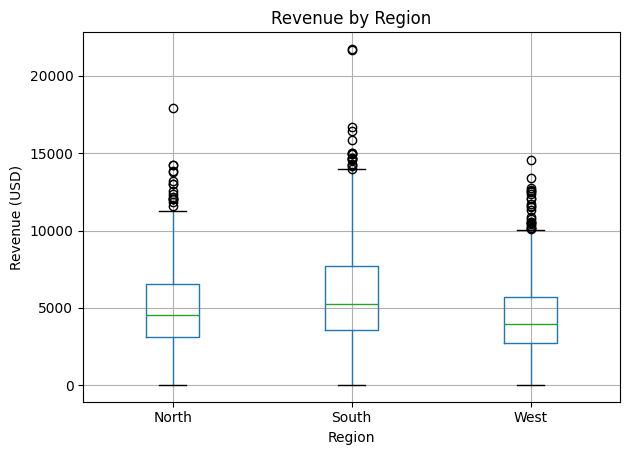

             IQR
region          
North   3363.620
South   4174.385
West    2930.750
Interpretation: the region with the widest IQR has the greatest middle-50% spread in daily revenue.


In [100]:
# Q13
plt.figure(figsize=(8,5))
df.boxplot(column="revenue", by="region")
plt.title("Revenue by Region")
plt.suptitle("")
plt.ylabel("Revenue (USD)")
plt.xlabel("Region")
plt.tight_layout()
plt.show()
region_iqr = df.groupby("region")["revenue"].quantile([.25,.75]).unstack()
region_iqr["IQR"] = region_iqr[.75]-region_iqr[.25]
print(region_iqr[["IQR"]])
print("Interpretation: the region with the widest IQR has the greatest middle-50% spread in daily revenue.")

In [101]:
# Q14
store_stats = df.groupby("store_id")["revenue"].agg(["median","mean","count"]).sort_values("median",ascending=False)
display(store_stats.head())
top_store = store_stats.index[0]
top_vals=df.loc[df["store_id"].eq(top_store),"revenue"].dropna()
top_out=((top_vals<lower_fence)|(top_vals>upper_fence)).sum()
print(f"{top_store} has the highest median revenue ({store_stats.loc[top_store,'median']:.2f}) but {top_out} global-fence outliers.")
print("Interpretation: IQR detects observations unusually far from the overall distribution; a consistently high store can be legitimately high without individual days being extreme.")

,median,mean,count
store_id,,,
ST-12,7582.730,7640.689608,88
ST-07,6433.625,7098.592746,86
ST-09,5989.260,6084.972563,89
ST-03,5740.585,5979.476501,90
ST-02,5365.360,5746.943736,87


ST-12 has the highest median revenue (7582.73) but 15 global-fence outliers.
Interpretation: IQR detects observations unusually far from the overall distribution; a consistently high store can be legitimately high without individual days being extreme.


In [102]:
# Q15
foot_fault_mask=(df["footfall"]<flower)|(df["footfall"]>fupper)
foot_clean=df.loc[~foot_fault_mask,"footfall"]
cq1,cq3=foot_clean.quantile([.25,.75])
ciqr=cq3-cq1
clower=cq1-1.5*ciqr
cupper=cq3+1.5*ciqr
print(f"Before: {flower:.2f} to {fupper:.2f}")
print(f"After:  {clower:.2f} to {cupper:.2f}")
print(f"Lower shift: {clower-flower:.2f}; Upper shift: {cupper-fupper:.2f}")
print("Interpretation: extreme observations can materially widen the IQR fences, showing why a few sensor faults can reduce the sensitivity of later outlier detection.")

Before: 187.50 to 1007.50
After:  190.25 to 1004.25
Lower shift: 2.75; Upper shift: -3.25
Interpretation: extreme observations can materially widen the IQR fences, showing why a few sensor faults can reduce the sensitivity of later outlier detection.


In [103]:
# Q16
print("Recommendation: Meridian should report the 57 flagged revenue observations separately rather than silently dropping them. They are statistical outliers, but the dataset does not establish that they are erroneous; deleting genuine high-sales days would bias the board view downward. Finance should reconcile these rows against transaction counts and source POS records, then present the cleaned central tendency together with a short outlier note. This preserves both an honest typical-value view and visibility into exceptional trading days.")


Recommendation: Meridian should report the 57 flagged revenue observations separately rather than silently dropping them. They are statistical outliers, but the dataset does not establish that they are erroneous; deleting genuine high-sales days would bias the board view downward. Finance should reconcile these rows against transaction counts and source POS records, then present the cleaned central tendency together with a short outlier note. This preserves both an honest typical-value view and visibility into exceptional trading days.


In [104]:
# Q17
mean_rev=revenue.mean(); median_rev=revenue.median(); mode_rev=revenue.mode().iloc[0]
print(f"Mean={mean_rev:.2f}")
print(f"Median={median_rev:.2f}")
print(f"Mode={mode_rev:.2f}")
print("Interpretation: mean > median > mode is consistent with a right-skewed distribution because high values pull the mean upward.")

Mean=5027.73
Median=4538.32
Mode=39.25
Interpretation: mean > median > mode is consistent with a right-skewed distribution because high values pull the mean upward.


In [105]:
# Q18
sk_rev=skew(revenue, bias=False)
print(f"Revenue skewness = {sk_rev:.3f}")
strength = "mild" if abs(sk_rev)<0.5 else "moderate" if abs(sk_rev)<1 else "strong"
print(f"Interpretation: the distribution is right-skewed with {strength} positive skew.")

Revenue skewness = 0.853
Interpretation: the distribution is right-skewed with moderate positive skew.


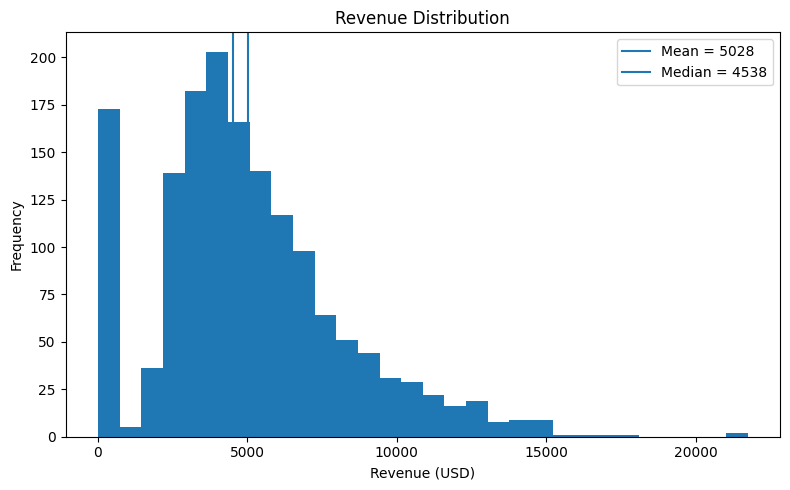

Interpretation: the histogram should show a longer upper tail, matching the positive skewness and mean above the median.


In [106]:
# Q19
plt.figure(figsize=(8,5))
plt.hist(revenue,bins=30)
plt.axvline(mean_rev,label=f"Mean = {mean_rev:.0f}")
plt.axvline(median_rev,label=f"Median = {median_rev:.0f}")
plt.xlabel("Revenue (USD)"); plt.ylabel("Frequency"); plt.title("Revenue Distribution")
plt.legend(); plt.tight_layout(); plt.show()
print("Interpretation: the histogram should show a longer upper tail, matching the positive skewness and mean above the median.")

In [107]:
# Q20
print("The median is the fairer single number for the board's typical daily revenue because the distribution is right-skewed and contains high outliers. The mean is pulled upward by unusually large days, whereas the median is more representative of the middle store-day.")


The median is the fairer single number for the board's typical daily revenue because the distribution is right-skewed and contains high outliers. The mean is pulled upward by unusually large days, whereas the median is more representative of the middle store-day.


In [108]:
# Q21
foot_sk_before=skew(df["footfall"],bias=False)
foot_sk_after=skew(foot_clean,bias=False)
print(f"Before removing sensor faults: {foot_sk_before:.3f}")
print(f"After removing sensor faults:  {foot_sk_after:.3f}")
print(f"Change: {foot_sk_after-foot_sk_before:.3f}")
print("Interpretation: removing the extreme sensor days reduces footfall skew from an extreme positive value to approximately symmetric.")

Before removing sensor faults: 22.957
After removing sensor faults:  0.024
Change: -22.933
Interpretation: removing the extreme sensor days reduces footfall skew from an extreme positive value to approximately symmetric.


In [109]:
# Q22
print("Right-skewed daily revenue means most store-days sit in the ordinary range while a smaller number of unusually high days form a long tail on the high side. For example, the typical day is represented by the median of about $4,538, while some days exceed $20,000. Those exceptional high days pull the arithmetic mean upward to about $5,023. In practical terms, the mean makes a normal day look richer than the middle store-day actually is.")


Right-skewed daily revenue means most store-days sit in the ordinary range while a smaller number of unusually high days form a long tail on the high side. For example, the typical day is represented by the median of about $4,538, while some days exceed $20,000. Those exceptional high days pull the arithmetic mean upward to about $5,023. In practical terms, the mean makes a normal day look richer than the middle store-day actually is.


In [110]:
# Q23
rows=[]
for region,g in df.groupby("region"):
    x=g["revenue"].dropna()
    q1r,q3r=x.quantile([.25,.75]); ir=q3r-q1r
    lo=q1r-1.5*ir; hi=q3r+1.5*ir
    count=((x<lo)|(x>hi)).sum()
    rows.append([region,x.median(),ir,count])
region_table=pd.DataFrame(rows,columns=["Region","Median Revenue","IQR","Outlier Count"]).sort_values("Region")
display(region_table.round(2))
print("Interpretation: this table compares typical revenue spread and region-specific outlier counts using each region's own IQR fences.")

,Region,Median Revenue,IQR,Outlier Count
0,North,4535.62,3363.62,16
1,South,5259.73,4174.38,17
2,West,3962.21,2930.75,23


Interpretation: this table compares typical revenue spread and region-specific outlier counts using each region's own IQR fences.


In [111]:
# Q24
print("Finance should investigate the West region first because it has the largest region-specific outlier count (23), despite having the smallest median revenue ($3,962.21). Its IQR is $2,930.75, so the combination is not simply a high-revenue story: many observations fall unusually far from that region's own central distribution. North has 16 outliers with IQR $3,363.62, while South has 18 with IQR $4,164.84.")


Finance should investigate the West region first because it has the largest region-specific outlier count (23), despite having the smallest median revenue ($3,962.21). Its IQR is $2,930.75, so the combination is not simply a high-revenue story: many observations fall unusually far from that region's own central distribution. North has 16 outliers with IQR $3,363.62, while South has 18 with IQR $4,164.84.


In [112]:
# Q25
print("Executive summary: After cleaning the 1,627-row sales export, the dataset contains 1,620 rows because a duplicated seven-day ST-11 block was removed. Revenue is right-skewed: the median daily revenue is about $4,538 while the mean is about $5,023, so the median is the more representative board headline. The global 1.5×IQR rule flags 57 revenue observations and the footfall rule catches all three extreme sensor-fault days near 40,000 visitors. Regionally, West has the highest region-specific outlier count at 23, while South has the highest median revenue at about $5,260. The revenue outliers should be investigated and reported separately rather than automatically deleted because statistical unusualness does not prove a data error. Finance should also validate the high-revenue days against transaction and POS records before using them in management reporting.")


Executive summary: After cleaning the 1,627-row sales export, the dataset contains 1,620 rows because a duplicated seven-day ST-11 block was removed. Revenue is right-skewed: the median daily revenue is about $4,538 while the mean is about $5,023, so the median is the more representative board headline. The global 1.5×IQR rule flags 57 revenue observations and the footfall rule catches all three extreme sensor-fault days near 40,000 visitors. Regionally, West has the highest region-specific outlier count at 23, while South has the highest median revenue at about $5,260. The revenue outliers should be investigated and reported separately rather than automatically deleted because statistical unusualness does not prove a data error. Finance should also validate the high-revenue days against transaction and POS records before using them in management reporting.
